<a href="https://www.kaggle.com/code/sonawanelalitsunil/traffic-violation-insights-india-ml-51-62?scriptVersionId=229995400" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/indian-traffic-violation/Indian_Traffic_Violations.csv


## Title: 🚦 Traffic Violation Insights - India

#### Description:
#### Analyzing traffic violations across India using machine learning. This project explores fine amounts, driver demographics, road conditions, and violation patterns while applying ML models to predict fine payments with high accuracy. 🚗📊

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/indian-traffic-violation/Indian_Traffic_Violations.csv')

In [3]:
df.head()

,Violation_ID,Violation_Type,Fine_Amount,Location,Date,Time,Vehicle_Type,Vehicle_Color,Vehicle_Model_Year,Registration_State,...,Speed_Limit,Recorded_Speed,Alcohol_Level,Breathalyzer_Result,Towed,Fine_Paid,Payment_Method,Court_Appearance_Required,Previous_Violations,Comments
0,VLT100000,Overloading,4544,Karnataka,2023-01-01,23:02,Car,Red,2012,West Bengal,...,100,95,0.03,Negative,Yes,No,Online,Yes,3,Repeat Offender
1,VLT100001,Driving Without License,2776,Punjab,2023-01-02,00:42,Scooter,Silver,2010,Tamil Nadu,...,40,48,0.45,Negative,Yes,Yes,Online,No,2,Repeat Offender
2,VLT100002,Using Mobile Phone,4785,Maharashtra,2023-01-03,04:32,Scooter,Grey,2006,Tamil Nadu,...,80,26,0.31,Not Conducted,No,No,Not Paid,Yes,4,NaN
3,VLT100003,No Seatbelt,1138,Uttar Pradesh,2023-01-04,15:06,Car,Green,1996,Uttar Pradesh,...,100,115,0.09,Not Conducted,No,Yes,Online,No,5,Repeat Offender
4,VLT100004,Over-speeding,1610,Karnataka,2023-01-05,06:57,Truck,Yellow,2016,Delhi,...,30,115,0.28,Positive,No,Yes,Cash,Yes,0,NaN


In [4]:
df.tail()

,Violation_ID,Violation_Type,Fine_Amount,Location,Date,Time,Vehicle_Type,Vehicle_Color,Vehicle_Model_Year,Registration_State,...,Speed_Limit,Recorded_Speed,Alcohol_Level,Breathalyzer_Result,Towed,Fine_Paid,Payment_Method,Court_Appearance_Required,Previous_Violations,Comments
3995,VLT103995,Signal Jumping,2180,Maharashtra,2033-12-09,04:18,Car,White,2000,Gujarat,...,100,90,0.15,Positive,Yes,No,Not Paid,Yes,2,NaN
3996,VLT103996,Using Mobile Phone,2708,Karnataka,2033-12-10,08:21,Scooter,Black,2018,Delhi,...,100,90,0.21,Negative,Yes,No,Card,No,4,First Violation
3997,VLT103997,Signal Jumping,3163,Delhi,2033-12-11,09:36,Bike,Yellow,1996,West Bengal,...,60,54,0.28,Negative,Yes,No,Online,No,2,First Violation
3998,VLT103998,No Seatbelt,1691,Gujarat,2033-12-12,02:46,Car,Black,1995,Delhi,...,30,77,0.28,Positive,No,Yes,Cash,No,2,NaN
3999,VLT103999,No Helmet,2133,Delhi,2033-12-13,09:14,Truck,Red,2010,Delhi,...,50,105,0.34,Not Conducted,No,No,Card,Yes,4,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Violation_ID               4000 non-null   object 
 1   Violation_Type             4000 non-null   object 
 2   Fine_Amount                4000 non-null   int64  
 3   Location                   4000 non-null   object 
 4   Date                       4000 non-null   object 
 5   Time                       4000 non-null   object 
 6   Vehicle_Type               4000 non-null   object 
 7   Vehicle_Color              4000 non-null   object 
 8   Vehicle_Model_Year         4000 non-null   int64  
 9   Registration_State         4000 non-null   object 
 10  Driver_Age                 4000 non-null   int64  
 11  Driver_Gender              4000 non-null   object 
 12  License_Type               4000 non-null   object 
 13  Penalty_Points             4000 non-null   int64

In [6]:
df.describe()

,Fine_Amount,Vehicle_Model_Year,Driver_Age,Penalty_Points,Number_of_Passengers,Speed_Limit,Recorded_Speed,Alcohol_Level,Previous_Violations
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.00000
mean,2529.821250,2008.910500,46.658000,4.960500,3.00050,59.817500,69.479000,0.251408,2.47750
std,1417.415712,8.333208,16.865858,3.157441,1.41085,23.633267,29.394652,0.143744,1.71398
min,100.000000,1995.000000,18.000000,0.000000,1.00000,30.000000,20.000000,0.000000,0.00000
25%,1280.750000,2002.000000,32.000000,2.000000,2.00000,40.000000,43.000000,0.130000,1.00000
50%,2506.000000,2009.000000,47.000000,5.000000,3.00000,60.000000,70.000000,0.250000,2.00000
75%,3733.000000,2016.000000,61.000000,8.000000,4.00000,80.000000,95.000000,0.380000,4.00000
max,5000.000000,2023.000000,75.000000,10.000000,5.00000,100.000000,120.000000,0.500000,5.00000


In [7]:
df.isnull().sum()

Violation_ID                    0
Violation_Type                  0
Fine_Amount                     0
Location                        0
Date                            0
Time                            0
Vehicle_Type                    0
Vehicle_Color                   0
Vehicle_Model_Year              0
Registration_State              0
Driver_Age                      0
Driver_Gender                   0
License_Type                    0
Penalty_Points                  0
Weather_Condition               0
Road_Condition                  0
Officer_ID                      0
Issuing_Agency                  0
License_Validity                0
Number_of_Passengers            0
Helmet_Worn                  1349
Seatbelt_Worn                1292
Traffic_Light_Status            0
Speed_Limit                     0
Recorded_Speed                  0
Alcohol_Level                   0
Breathalyzer_Result             0
Towed                           0
Fine_Paid                       0
Payment_Method

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(4000, 33)

In [10]:
df.dtypes

Violation_ID                  object
Violation_Type                object
Fine_Amount                    int64
Location                      object
Date                          object
Time                          object
Vehicle_Type                  object
Vehicle_Color                 object
Vehicle_Model_Year             int64
Registration_State            object
Driver_Age                     int64
Driver_Gender                 object
License_Type                  object
Penalty_Points                 int64
Weather_Condition             object
Road_Condition                object
Officer_ID                    object
Issuing_Agency                object
License_Validity              object
Number_of_Passengers           int64
Helmet_Worn                   object
Seatbelt_Worn                 object
Traffic_Light_Status          object
Speed_Limit                    int64
Recorded_Speed                 int64
Alcohol_Level                float64
Breathalyzer_Result           object
T

In [11]:
df.columns

Index(['Violation_ID', 'Violation_Type', 'Fine_Amount', 'Location', 'Date',
       'Time', 'Vehicle_Type', 'Vehicle_Color', 'Vehicle_Model_Year',
       'Registration_State', 'Driver_Age', 'Driver_Gender', 'License_Type',
       'Penalty_Points', 'Weather_Condition', 'Road_Condition', 'Officer_ID',
       'Issuing_Agency', 'License_Validity', 'Number_of_Passengers',
       'Helmet_Worn', 'Seatbelt_Worn', 'Traffic_Light_Status', 'Speed_Limit',
       'Recorded_Speed', 'Alcohol_Level', 'Breathalyzer_Result', 'Towed',
       'Fine_Paid', 'Payment_Method', 'Court_Appearance_Required',
       'Previous_Violations', 'Comments'],
      dtype='object')

## Data visualizations

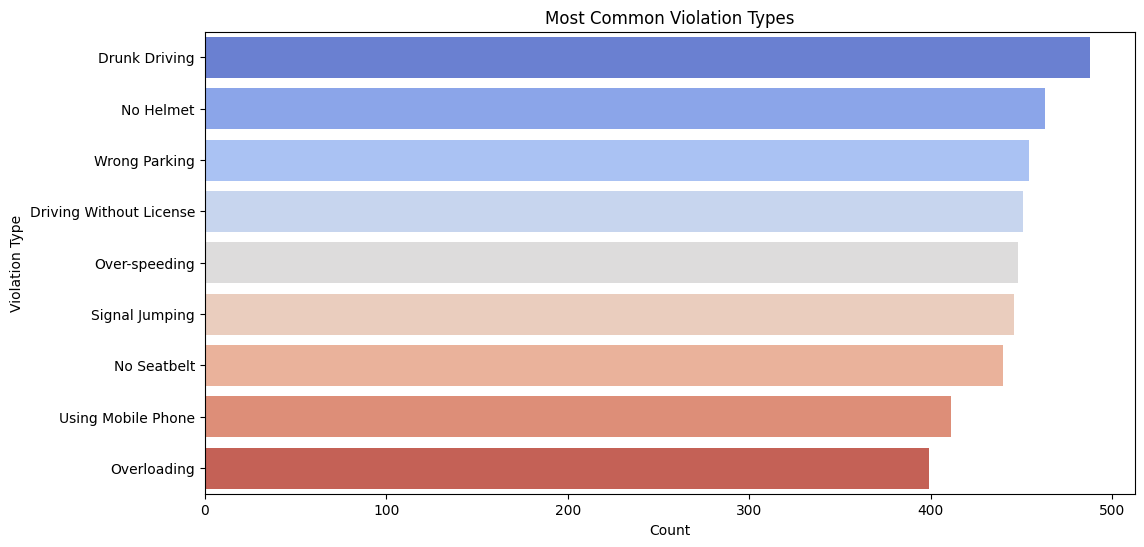

In [12]:
# 1. Violation Type Frequency
plt.figure(figsize=(12, 6))
sns.countplot(y=df['Violation_Type'], order=df['Violation_Type'].value_counts().index, palette='coolwarm')
plt.title('Most Common Violation Types')
plt.xlabel('Count')
plt.ylabel('Violation Type')
plt.show()

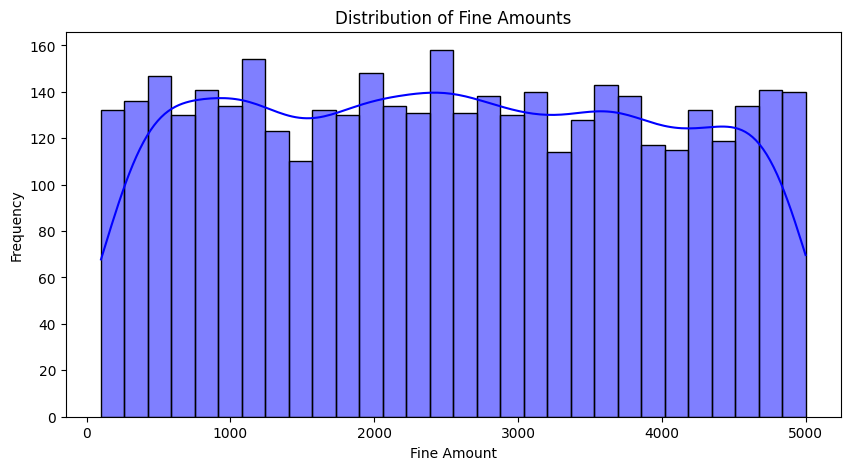

In [13]:
# 2. Fine Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Fine_Amount'], bins=30, kde=True, color='blue')
plt.title('Distribution of Fine Amounts')
plt.xlabel('Fine Amount')
plt.ylabel('Frequency')
plt.show()

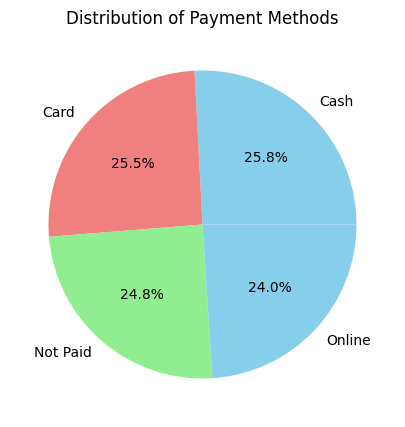

In [14]:
# 3. Payment Method Distribution
plt.figure(figsize=(8, 5))
df['Payment_Method'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Distribution of Payment Methods')
plt.ylabel('')
plt.show()

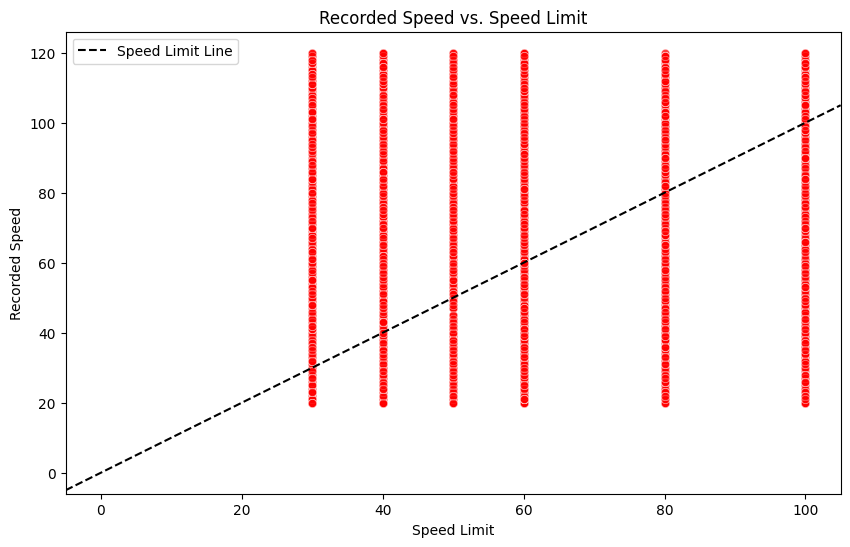

In [15]:
# 4. Speed Limit vs Recorded Speed
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Speed_Limit'], y=df['Recorded_Speed'], alpha=0.5, color='red')
plt.axline((0, 0), slope=1, linestyle='--', color='black', label='Speed Limit Line')
plt.title('Recorded Speed vs. Speed Limit')
plt.xlabel('Speed Limit')
plt.ylabel('Recorded Speed')
plt.legend()
plt.show()

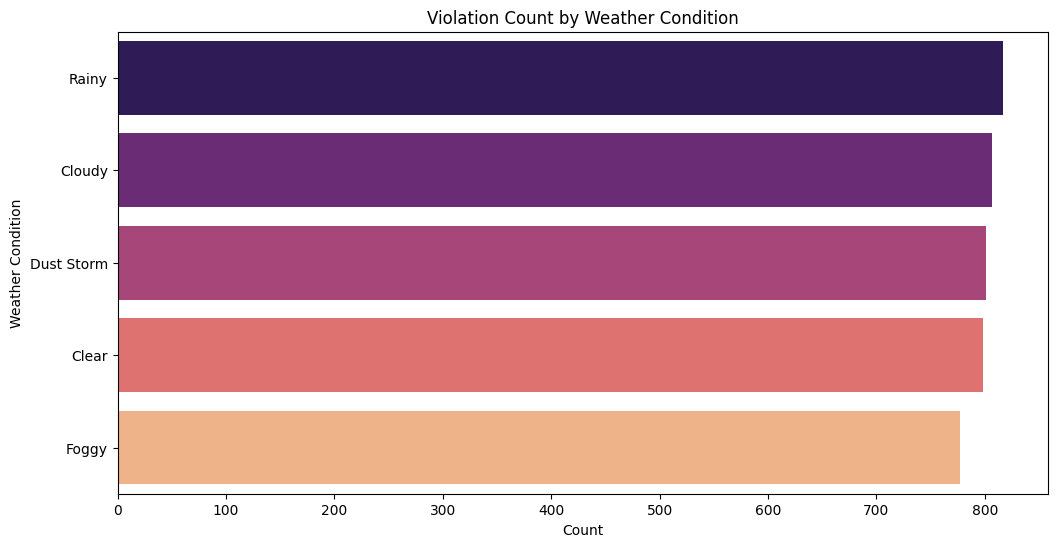

In [16]:
# 5. Weather Condition Impact on Violations
plt.figure(figsize=(12, 6))
sns.countplot(y=df['Weather_Condition'], order=df['Weather_Condition'].value_counts().index, palette='magma')
plt.title('Violation Count by Weather Condition')
plt.xlabel('Count')
plt.ylabel('Weather Condition')
plt.show()

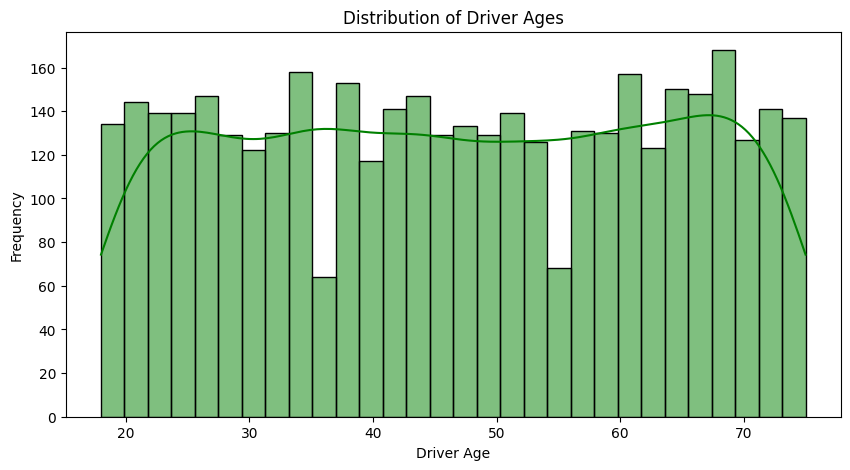

In [17]:
# 6. Driver Age Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Driver_Age'], bins=30, kde=True, color='green')
plt.title('Distribution of Driver Ages')
plt.xlabel('Driver Age')
plt.ylabel('Frequency')
plt.show()

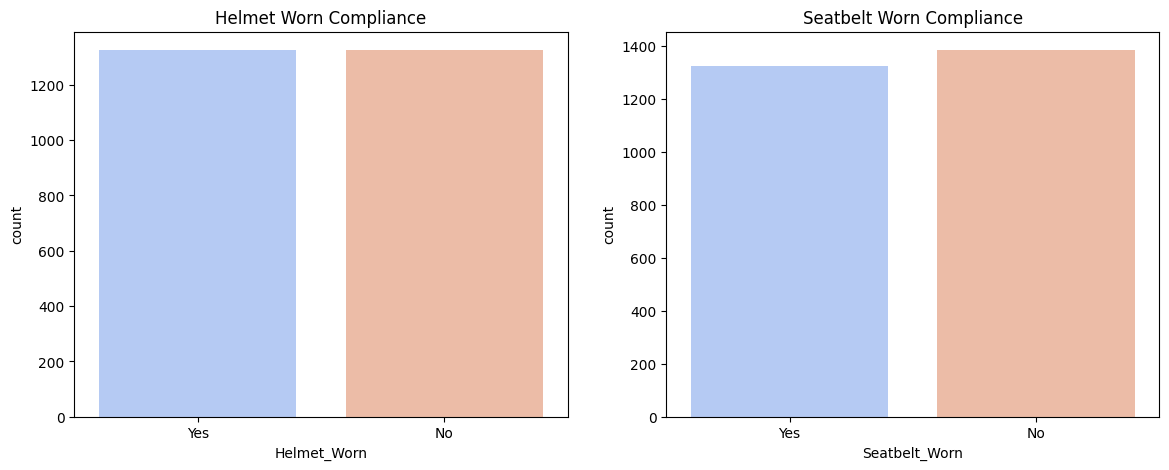

In [18]:
# 7. Helmet & Seatbelt Compliance
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x=df['Helmet_Worn'], ax=ax[0], palette='coolwarm')
ax[0].set_title('Helmet Worn Compliance')
sns.countplot(x=df['Seatbelt_Worn'], ax=ax[1], palette='coolwarm')
ax[1].set_title('Seatbelt Worn Compliance')
plt.show()

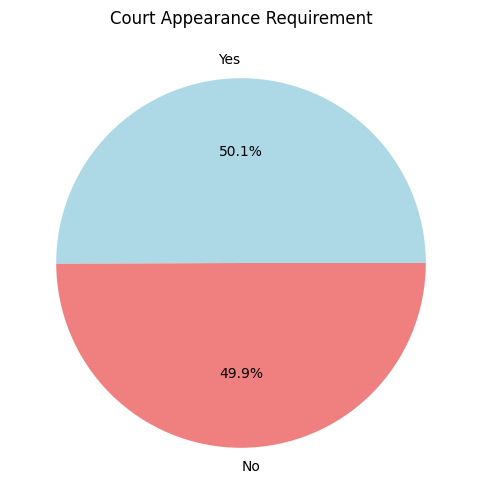

In [19]:
# 8. Court Appearance Required
plt.figure(figsize=(6, 6))
df['Court_Appearance_Required'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Court Appearance Requirement')
plt.ylabel('')
plt.show()

## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [21]:
# Drop non-numeric columns that are not needed for ML
categorical_cols = ['Violation_ID', 'Date', 'Time', 'Comments', 'Officer_ID', 'Issuing_Agency']
df.drop(columns=categorical_cols, inplace=True, errors='ignore')

In [22]:
# Label Encoding for categorical features
le = LabelEncoder()
categorical_features = df.select_dtypes(include=['object']).columns
for col in categorical_features:
    df[col] = le.fit_transform(df[col].astype(str))

In [23]:
# Handling missing values (if any)
df.fillna(df.median(), inplace=True)

In [24]:
# Splitting data into features and target
X = df.drop(columns=['Fine_Paid'])  # Assuming 'Fine_Paid' is the target variable
y = df['Fine_Paid']

In [25]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# Scaling the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier()
}

In [28]:
# Train and evaluate models
accuracy_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_results[name] = accuracy

In [29]:
# Display accuracy results
print("Model Accuracy:")
for model, acc in accuracy_results.items():
    print(f"{model}: {acc:.2%}")

Model Accuracy:
Logistic Regression: 51.12%
Random Forest: 46.50%
Gradient Boosting: 48.38%
SVM: 52.38%
KNN: 49.00%
Decision Tree: 49.50%


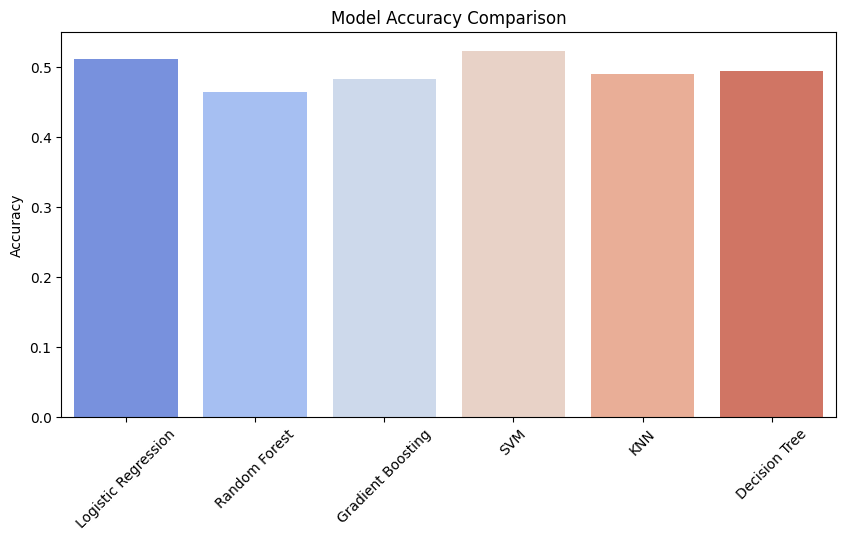

In [30]:
# Plot accuracy comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=list(accuracy_results.keys()), y=list(accuracy_results.values()), palette='coolwarm')
plt.xticks(rotation=45)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()

## Thank you!!!!..pls upvote!!!